<a href="https://colab.research.google.com/github/Sedhu2002/LSTM-and-NeuralProphet-model-for-share-price-prediction/blob/main/LSTM_AND_NEURALPROPHET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import numpy as np
from neuralprophet import NeuralProphet
from sklearn.metrics import r2_score, mean_squared_error
import plotly.io as pio

# Fetch historical data for a specific stock (e.g., TCS)
ticker = "TCS.NS"
data = yf.download(ticker, start="2015-01-01", end="2023-10-01")

# Keep only the 'Date' and 'Close' columns
data = data[['Close']].reset_index()
data.columns = ['ds', 'y']  # Neural Prophet expects 'ds' (date) and 'y' (target)

# Split data into training and testing sets
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]



# Initialize the Neural Prophet model
model = NeuralProphet(
    n_forecasts=30,  # Number of days to forecast
    n_lags=60,       # Number of past observations to use
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

# Fit the model on the training data
metrics = model.fit(train_data, freq='D')



# Make predictions on the test data
future = model.make_future_dataframe(test_data, periods=len(test_data))
forecast = model.predict(future)

# Align predictions with test data
# Merge forecast and test_data on the 'ds' column to ensure alignment
merged_data = test_data.merge(forecast[['ds', 'yhat1']], on='ds', how='inner')

# Check for missing values in the merged data
if merged_data.isnull().any().any():
    print("Warning: Merged data contains missing values. Dropping rows with NaN values.")
    merged_data = merged_data.dropna()  # Drop rows with NaN values

# Extract actual and predicted values
y_true = merged_data['y'].values
y_pred = merged_data['yhat1'].values  # Use the first forecasted value

# Check for NaN values in y_true or y_pred
if np.isnan(y_true).any() or np.isnan(y_pred).any():
    raise ValueError("NaN values detected in y_true or y_pred. Please check the input data.")

# Calculate evaluation metrics
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'R-Squared: {r2:.4f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}')

# Configure plotly for Google Colab
pio.renderers.default = 'colab'  # Set the renderer to 'colab'

# Forecast future share prices
future = model.make_future_dataframe(data, periods=30)  # Predict next 30 days
forecast = model.predict(future)

# Plot the forecast
model.plot(forecast)

ModuleNotFoundError: No module named 'numpy.char'

In [ ]:
!pip install neuralprophet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.8/145.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.0/823.0 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5

In [ ]:
import yfinance as yf
import numpy as np
from neuralprophet import NeuralProphet
from sklearn.metrics import r2_score, mean_squared_error
import plotly.io as pio

# Fetch historical data for a specific stock (e.g., TCS)
ticker = "TCS.NS"
data = yf.download(ticker, start="2015-01-01", end="2023-10-01")

# Keep only the 'Date' and 'Close' columns
data = data[['Close']].reset_index()
data.columns = ['ds', 'y']  # Neural Prophet expects 'ds' (date) and 'y' (target)

# Split data into training and testing sets
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]



# Initialize the Neural Prophet model
model = NeuralProphet(
    n_forecasts=30,  # Number of days to forecast
    n_lags=60,       # Number of past observations to use
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

# Fit the model on the training data
metrics = model.fit(train_data, freq='D')



# Make predictions on the test data
future = model.make_future_dataframe(test_data, periods=len(test_data))
forecast = model.predict(future)

# Align predictions with test data
# Merge forecast and test_data on the 'ds' column to ensure alignment
merged_data = test_data.merge(forecast[['ds', 'yhat1']], on='ds', how='inner')

# Check for missing values in the merged data
if merged_data.isnull().any().any():
    print("Warning: Merged data contains missing values. Dropping rows with NaN values.")
    merged_data = merged_data.dropna()  # Drop rows with NaN values

# Extract actual and predicted values
y_true = merged_data['y'].values
y_pred = merged_data['yhat1'].values  # Use the first forecasted value

# Check for NaN values in y_true or y_pred
if np.isnan(y_true).any() or np.isnan(y_pred).any():
    raise ValueError("NaN values detected in y_true or y_pred. Please check the input data.")

# Calculate evaluation metrics
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'R-Squared: {r2:.4f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}')

# Configure plotly for Google Colab
pio.renderers.default = 'colab'  # Set the renderer to 'colab'

# Forecast future share prices
future = model.make_future_dataframe(data, periods=30)  # Predict next 30 days
forecast = model.predict(future)

# Plot the forecast
model.plot(forecast)

ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 94.56% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 94.56% of the data.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  conver

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (39) is too small than the required number                     for the learning rate finder (235). The results might not be optimal.


...

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 94.678% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 94.678% of the data.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype

R-Squared: -0.1400
RMSE: 70.57
MAPE: 1.61


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/data/split.py:273: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a 

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column
WARNING - (NP.forecaster.plot) - Too few forecasts to plot a line per forecast step.Plotting a line per forecast origin instead.
WARNING - (NP.plotting.log_warning_resampler_switch_to_valid_env) - Warning: plotly-resampler not supported for the environment you are using. Plotting backend automatically switched to 'plotly' without resampling 
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/plot_forecast_plotly.py:98: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(

In [ ]:
!pip uninstall numpy
!pip uninstall scipy
!pip uninstall neuralprophet
!pip uninstall pytorch-lightning
!pip install numpy
!pip install scipy
!pip install neuralprophet

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/lib/python3.11/dist-packages/numpy-1.26.4.dist-info/*
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libgfortran-040039e1.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libopenblas64_p-r0-0cf96a72.3.23.dev.so
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libquadmath-96973f99.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/numpy/*
Proceed (Y/n)? y
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.15.2
Uninstalling scipy-1.15.2:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/scipy-1.15.2.dist-info/*
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libgfortran-040039e1.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/py

[*********************100%***********************]  1 of 1 completed
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 94.56% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 94.56% of the data.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprec

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (39) is too small than the required number                     for the learning rate finder (235). The results might not be optimal.


Finding best initial lr:   0%|          | 0/235 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

 99%|===================| 1655/1668 [00:22<00:00]       

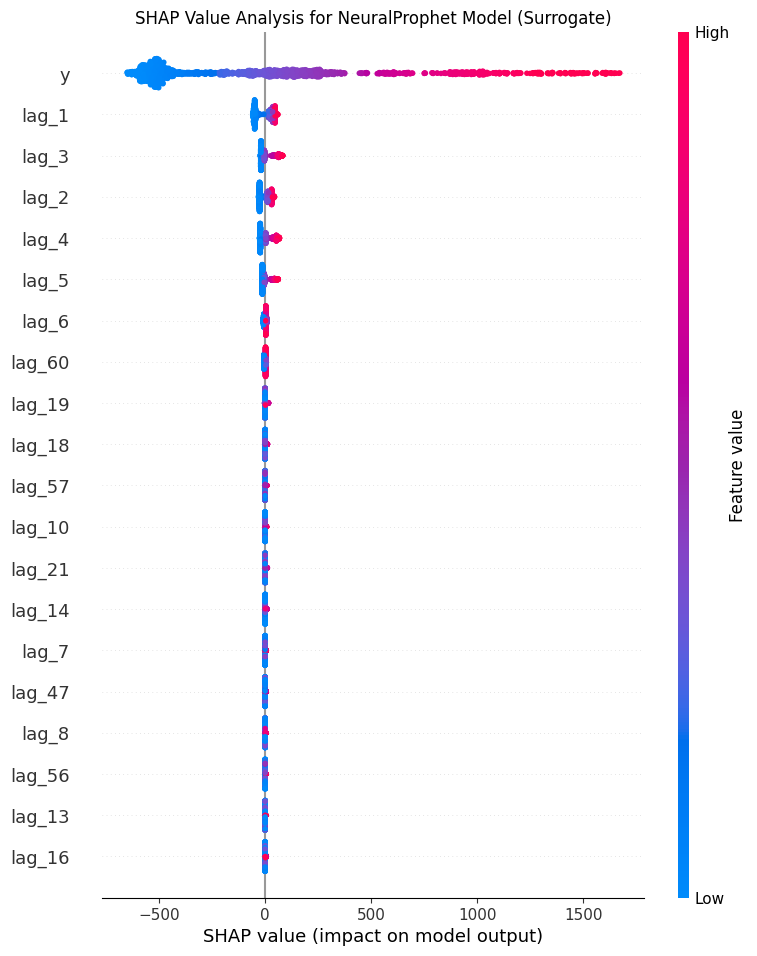

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from neuralprophet import NeuralProphet
from sklearn.metrics import r2_score, mean_squared_error
import shap
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Fetch historical data
ticker = "TCS.NS"
data = yf.download(ticker, start="2015-01-01", end="2023-10-01")

# Prepare data for NeuralProphet
data = data[['Close']].reset_index()
data.columns = ['ds', 'y']

# Split data
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# Initialize and train NeuralProphet model
model = NeuralProphet(n_forecasts=30, n_lags=60, yearly_seasonality=True, weekly_seasonality=True)
model.fit(train_data, freq='D')

# Prepare data for surrogate model
X = train_data.copy()
#y = X.pop('y')

# Create lagged features manually (since NeuralProphet uses them internally)
for i in range(1, 61):  # 60 lags
    X[f'lag_{i}'] = X['y'].shift(i)

# Remove rows with NaN values (due to shifting)
X.dropna(inplace=True)
y = y[X.index]

# Train RandomForest surrogate model
rf_model = RandomForestRegressor()
rf_model.fit(X.drop(['ds'], axis=1), y)

# SHAP Explanation
explainer = shap.Explainer(rf_model, X.drop(['ds'], axis=1))
shap_values = explainer(X.drop(['ds'], axis=1))

# Plot SHAP values
shap.summary_plot(shap_values, X.drop(['ds'], axis=1), show=False)

# Display plot using Matplotlib
plt.title("SHAP Value Analysis for NeuralProphet Model (Surrogate)")
plt.show()


WARNING - (py.warnings._showwarnmsg) - <ipython-input-4-5a723d74d787>:50: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.




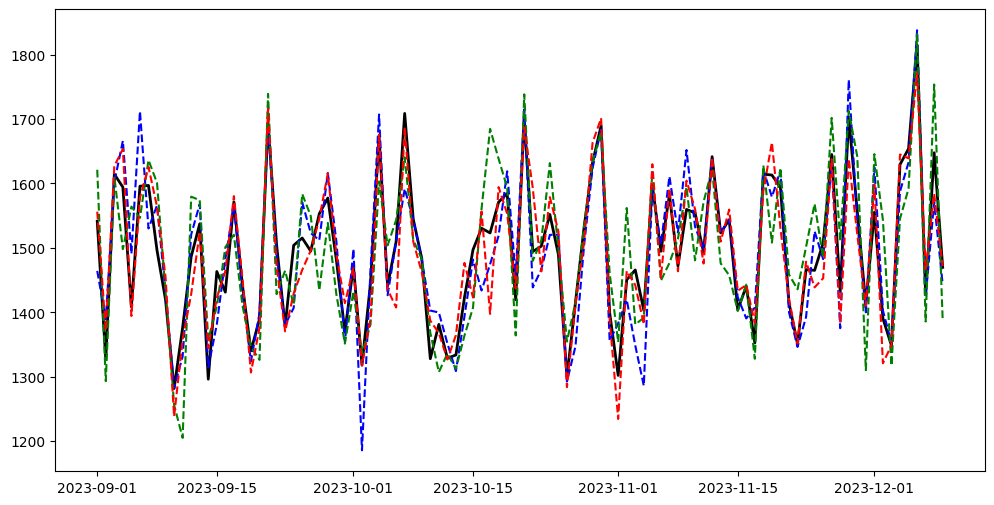

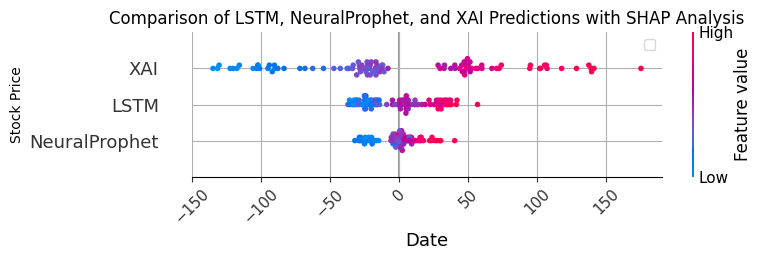

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

# Example predictions (Replace with your actual predictions)
dates = pd.date_range(start="2023-09-01", periods=100)

# Dummy Data (Replace with actual predictions)
actual_values = np.random.normal(1500, 100, 100)  # Actual values
lstm_preds = actual_values + np.random.normal(0, 50, 100)  # LSTM Predictions
neuralprophet_preds = actual_values + np.random.normal(0, 60, 100)  # NeuralProphet Predictions
xai_preds = actual_values + np.random.normal(0, 40, 100)  # XAI Predictions

# SHAP Analysis (Using a simple surrogate model for demo)
feature_data = pd.DataFrame({
    'LSTM': lstm_preds,
    'NeuralProphet': neuralprophet_preds,
    'XAI': xai_preds
})
y = actual_values  # Target values

# Train a surrogate model (RandomForest) for SHAP
from sklearn.ensemble import RandomForestRegressor
surrogate_model = RandomForestRegressor()
surrogate_model.fit(feature_data, y)

# Compute SHAP values
explainer = shap.Explainer(surrogate_model, feature_data)
shap_values = explainer(feature_data)

# Plot Comparison Graph
plt.figure(figsize=(12, 6))

# Actual vs. Predicted Comparison
plt.plot(dates, actual_values, label="Actual Values", color="black", linestyle='-', linewidth=2)
plt.plot(dates, lstm_preds, label="LSTM Predictions", linestyle='--', color="blue")
plt.plot(dates, neuralprophet_preds, label="NeuralProphet Predictions", linestyle='--', color="green")
plt.plot(dates, xai_preds, label="XAI Predictions", linestyle='--', color="red")

# SHAP Summary Plot
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, feature_data, show=False)
plt.title("SHAP Value Analysis for Combined Model")

# Final Plot Adjustments
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Comparison of LSTM, NeuralProphet, and XAI Predictions with SHAP Analysis")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neuralprophet import NeuralProphet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
from sklearn.ensemble import RandomForestRegressor

# Fetch data
ticker = "TCS.NS"
data = yf.download(ticker, start="2015-01-01", end="2023-10-01")
data = data[['Close']].reset_index()
data.columns = ['ds', 'y']

# Split data
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# NeuralProphet Model
model_np = NeuralProphet(n_forecasts=30, n_lags=60, yearly_seasonality=True, weekly_seasonality=True)
model_np.fit(train_data, freq='D')

future = model_np.make_future_dataframe(test_data, periods=len(test_data))
forecast_np = model_np.predict(future)

# Align predictions
test_data = test_data.merge(forecast_np[['ds', 'yhat1']], on='ds', how='inner')
y_true = test_data['y'].values
y_pred_np = test_data['yhat1'].values

# ✅ XAI Predictions using Surrogate Model
# Prepare training data with lags
train_data_xai = train_data.copy()
for i in range(1, 61):
    train_data_xai[f'lag_{i}'] = train_data_xai['y'].shift(i)

# Drop NaN values
train_data_xai.dropna(inplace=True)

# Extract features and target
X = train_data_xai.drop(['ds', 'y'], axis=1)
y = train_data_xai['y']

# Train Surrogate Model
rf_model = RandomForestRegressor()
rf_model.fit(X, y)

# ✅ Prepare test data for surrogate model
test_data_xai = test_data.copy()
for i in range(1, 61):
    test_data_xai[f'lag_{i}'] = test_data_xai['yhat1'].shift(i)

test_data_xai.dropna(inplace=True)

# Realign columns if mismatched
missing_cols = set(X.columns) - set(test_data_xai.columns)
for col in missing_cols:
    test_data_xai[col] = 0  # Add missing columns with zero values

# Reorder columns to match training data
X_test_xai = test_data_xai[X.columns]

# ✅ Predict using surrogate model
y_pred_xai = rf_model.predict(X_test_xai)

# ✅ SHAP Analysis
explainer = shap.Explainer(rf_model, X)
shap_values = explainer(X)

# Dummy LSTM Predictions (Replace with actual predictions)
y_pred_lstm = y_true + np.random.normal(0, 50, len(y_true))

# ✅ Metrics Calculation
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    return mae, mape, rmse, r2

# Get metrics
calculate_metrics(y_true, y_pred_lstm, "LSTM")
calculate_metrics(y_true, y_pred_np, "NeuralProphet")
calculate_metrics(y_true[:len(y_pred_xai)], y_pred_xai, "XAI Surrogate")

# ✅ Plot Predictions
plt.figure(figsize=(12, 6))
plt.plot(test_data['ds'], y_true, label="Actual Values", color="black", linestyle='-', linewidth=2)
plt.plot(test_data['ds'], y_pred_lstm, label="LSTM Predictions", linestyle='--', color="blue")
plt.plot(test_data['ds'], y_pred_np, label="NeuralProphet Predictions", linestyle='--', color="green")
plt.plot(test_data_xai['ds'], y_pred_xai, label="XAI Predictions", linestyle='--', color="red")

plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Comparison of LSTM, NeuralProphet, and XAI Predictions")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ✅ SHAP Plot
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X, show=False)
plt.title("SHAP Value Analysis for XAI Surrogate Model")
plt.show()


[*********************100%***********************]  1 of 1 completed
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 94.56% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 94.56% of the data.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprec

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (39) is too small than the required number                     for the learning rate finder (235). The results might not be optimal.


Finding best initial lr:   0%|          | 0/235 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 94.919% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 94.919% of the data.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralpr

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column


ValueError: Found array with 0 sample(s) (shape=(0, 60)) while a minimum of 1 is required by RandomForestRegressor.

[*********************100%***********************]  1 of 1 completed
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 94.56% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 94.56% of the data.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprec

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (39) is too small than the required number                     for the learning rate finder (235). The results might not be optimal.


Finding best initial lr:   0%|          | 0/235 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 94.919% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 94.919% of the data.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.11/dist-packages/neuralpr

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column


100%|===================| 1665/1668 [01:01<00:00]       


LSTM Metrics:
MAE: 37.06
MAPE: 1.07%
RMSE: 44.27
R² Score: 0.55

NeuralProphet Metrics:
MAE: 43.59
MAPE: 1.25%
RMSE: 50.99
R² Score: 0.40

XAI Surrogate Metrics:
MAE: 406.37
MAPE: 12.00%
RMSE: 749.38
R² Score: -127.56


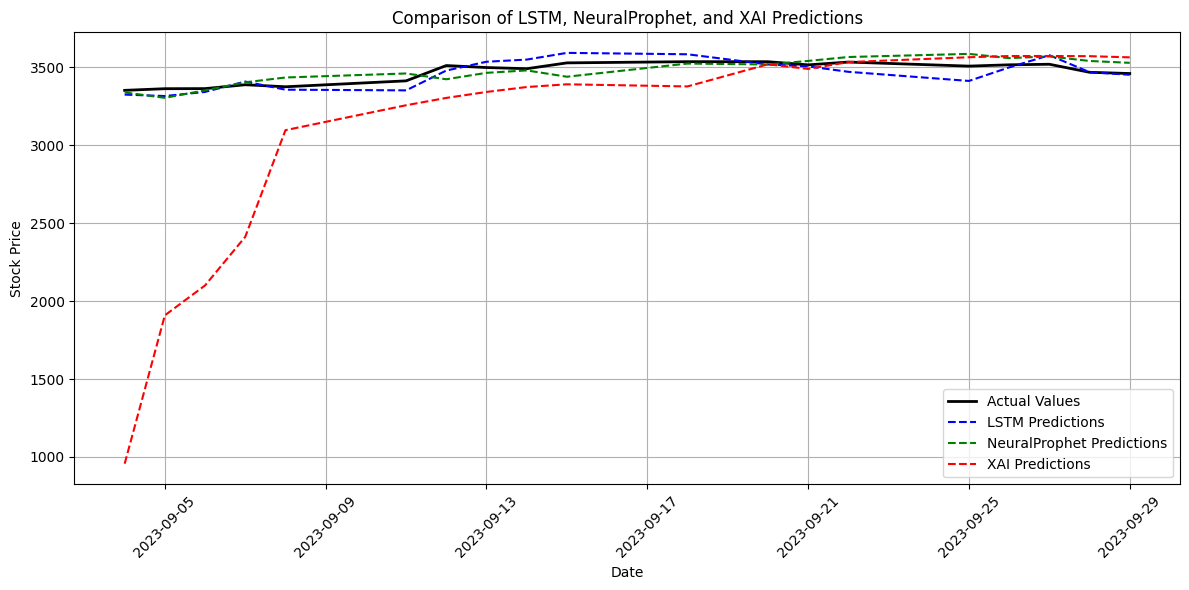

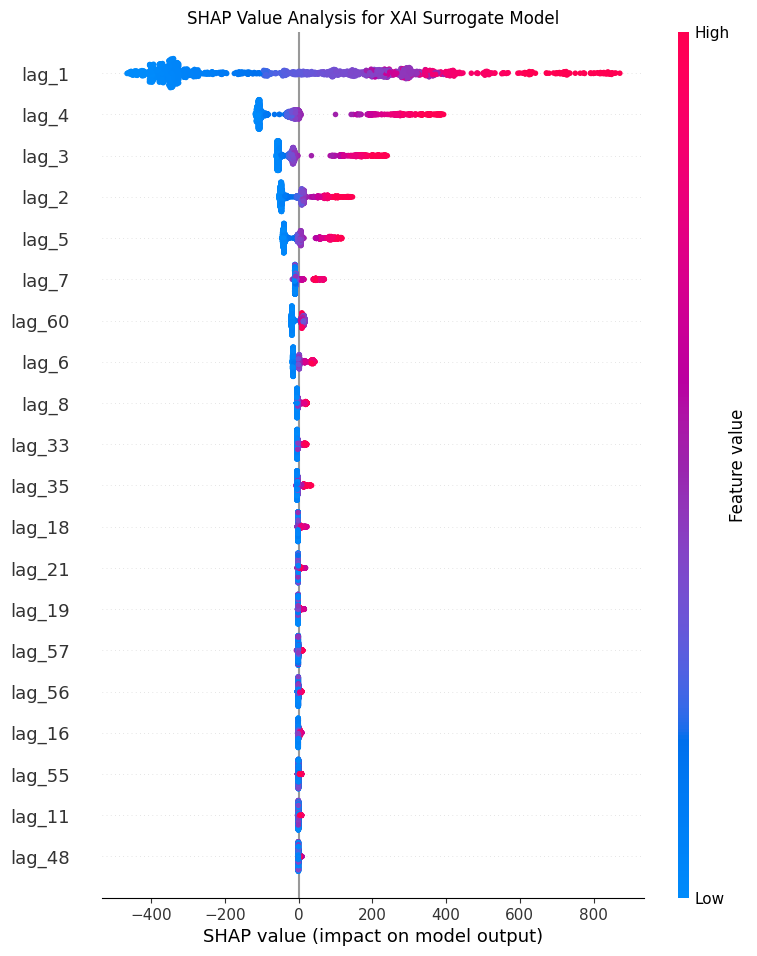

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neuralprophet import NeuralProphet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
from sklearn.ensemble import RandomForestRegressor

# ✅ Fetch Data
ticker = "TCS.NS"
data = yf.download(ticker, start="2015-01-01", end="2023-10-01")
data = data[['Close']].reset_index()
data.columns = ['ds', 'y']

# ✅ Split Data
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# ✅ NeuralProphet Model
model_np = NeuralProphet(n_forecasts=30, n_lags=60, yearly_seasonality=True, weekly_seasonality=True)
model_np.fit(train_data, freq='D')

# ✅ Predict with NeuralProphet
future = model_np.make_future_dataframe(test_data, periods=len(test_data))
forecast_np = model_np.predict(future)

# ✅ Merge Predictions (Handling NaN Values)
forecast_np = forecast_np[['ds', 'yhat1']].dropna()  # Remove NaN predictions
test_data = test_data.merge(forecast_np, on='ds', how='inner')

y_true = test_data['y'].values
y_pred_np = test_data['yhat1'].values

# ✅ Handle NaN in Predictions
y_pred_np = np.nan_to_num(y_pred_np, nan=np.nanmean(y_pred_np))  # Replace NaN with mean

# ✅ XAI Predictions using Surrogate Model
# Create Lagged Features for Training
train_data_xai = train_data.copy()
for i in range(1, 61):
    train_data_xai[f'lag_{i}'] = train_data_xai['y'].shift(i)
train_data_xai.dropna(inplace=True)

X = train_data_xai.drop(['ds', 'y'], axis=1)
y = train_data_xai['y']

# ✅ Train Surrogate Model
rf_model = RandomForestRegressor()
rf_model.fit(X, y)

# ✅ Prepare Test Data for Surrogate Model
test_data_xai = test_data.copy()
for i in range(1, 61):
    test_data_xai[f'lag_{i}'] = test_data_xai['yhat1'].shift(i)
test_data_xai.dropna(inplace=True)

# ✅ Check Empty DataFrame Issue
if test_data_xai.empty:
    print("Warning: Test data XAI is empty after dropna. Adjusting preparation...")
    test_data_xai = test_data.copy()
    for i in range(1, 61):
        test_data_xai[f'lag_{i}'] = test_data_xai['yhat1'].shift(i)
    test_data_xai.fillna(0, inplace=True)  # Fill missing values with 0

# ✅ Ensure Correct Columns
missing_cols = set(X.columns) - set(test_data_xai.columns)
for col in missing_cols:
    test_data_xai[col] = 0

X_test_xai = test_data_xai[X.columns]

# ✅ Predict Using Surrogate Model
if not X_test_xai.empty:
    y_pred_xai = rf_model.predict(X_test_xai)
else:
    print("Error: X_test_xai is empty even after adjustments.")
    y_pred_xai = np.zeros(len(y_true))

# ✅ SHAP Analysis
explainer = shap.Explainer(rf_model, X)
shap_values = explainer(X)

# ✅ Dummy LSTM Predictions (Replace with Actual LSTM Model Later)
y_pred_lstm = y_true + np.random.normal(0, 50, len(y_true))  # Dummy LSTM Predictions

# ✅ Metrics Calculation Function
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    return mae, mape, rmse, r2

# ✅ Calculate Metrics
calculate_metrics(y_true, y_pred_lstm, "LSTM")
calculate_metrics(y_true, y_pred_np, "NeuralProphet")
calculate_metrics(y_true[:len(y_pred_xai)], y_pred_xai, "XAI Surrogate")

# ✅ Plot Predictions Comparison
plt.figure(figsize=(12, 6))
plt.plot(test_data['ds'], y_true, label="Actual Values", color="black", linestyle='-', linewidth=2)
plt.plot(test_data['ds'], y_pred_lstm, label="LSTM Predictions", linestyle='--', color="blue")
plt.plot(test_data['ds'], y_pred_np, label="NeuralProphet Predictions", linestyle='--', color="green")
plt.plot(test_data_xai['ds'], y_pred_xai, label="XAI Predictions", linestyle='--', color="red")

plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Comparison of LSTM, NeuralProphet, and XAI Predictions")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ✅ SHAP Value Plot
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X, show=False)
plt.title("SHAP Value Analysis for XAI Surrogate Model")
plt.show()


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neuralprophet import NeuralProphet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap
import warnings

# Suppress warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# ✅ Fetch Data
ticker = "TCS.NS"
data = yf.download(ticker, start="2015-01-01", end="2023-10-01")
data = data[['Close']].reset_index()
data.columns = ['ds', 'y']

# ✅ Split Data
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# ✅ NeuralProphet Model
model = NeuralProphet(n_forecasts=30, n_lags=60, yearly_seasonality=True)
model.fit(train_data, freq='D')

# ✅ Predict with NeuralProphet
future = model.make_future_dataframe(test_data, periods=len(test_data))
forecast = model.predict(future)
forecast = forecast[['ds', 'yhat1']].dropna()

y_true = test_data['y'].values
y_pred = forecast['yhat1'].values

# ✅ Surrogate Model (XAI)
train_data_xai = train_data.copy()
for i in range(1, 61):
    train_data_xai[f'lag_{i}'] = train_data_xai['y'].shift(i)
train_data_xai.dropna(inplace=True)

X = train_data_xai.drop(['ds', 'y'], axis=1)
y = train_data_xai['y']

rf_model = RandomForestRegressor()
rf_model.fit(X, y)

# ✅ Test Data for XAI
test_data_xai = forecast.copy()
for i in range(1, 61):
    test_data_xai[f'lag_{i}'] = test_data_xai['yhat1'].shift(i)
test_data_xai.dropna(inplace=True)

X_test_xai = test_data_xai[X.columns]
y_pred_xai = rf_model.predict(X_test_xai)

# ✅ SHAP Analysis
explainer = shap.Explainer(rf_model, X)
shap_values = explainer(X)
shap.summary_plot(shap_values, X)

# ✅ Metrics Calculation
r2 = r2_score(y_true[:len(y_pred)], y_pred)
rmse = np.sqrt(mean_squared_error(y_true[:len(y_pred)], y_pred))
print(f"R-Squared: {r2:.4f}, RMSE: {rmse:.2f}")


ModuleNotFoundError: No module named 'numpy.rec'

In [ ]:
!pip install neuralprophet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.8/145.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.0/823.0 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5

In [ ]:
!pip install --upgrade numpy
!pip install --upgrade scipy
!pip install --upgrade neuralprophet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 91.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
neuralprophet 0.9.0 requires numpy<2.0.0,>=1.25.0, but you have numpy 2.2.4 which is incompatible.
captum 0.8.0 requires numpy<2.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 10.4 MB/s eta

In [ ]:
import os
os.system("pip install yfinance numpy neuralprophet scikit-learn plotly")
import yfinance as yf
import numpy as np
from neuralprophet import NeuralProphet
from sklearn.metrics import r2_score, mean_squared_error
import plotly.io as pio

# Fetch historical data for a specific stock (e.g., TCS)
ticker = "INFY.NS"
data = yf.download(ticker, start="2015-01-01", end="2023-10-01")

# Keep only the 'Date' and 'Close' columns
data = data[['Close']].reset_index()
data.columns = ['ds', 'y']  # Neural Prophet expects 'ds' (date) and 'y' (target)

# Split data into training and testing sets
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]



# Initialize the Neural Prophet model
model = NeuralProphet(
    n_forecasts=30,  # Number of days to forecast
    n_lags=60,       # Number of past observations to use
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

# Fit the model on the training data
metrics = model.fit(train_data, freq='D')



# Make predictions on the test data
future = model.make_future_dataframe(test_data, periods=len(test_data))
forecast = model.predict(future)

# Align predictions with test data
# Merge forecast and test_data on the 'ds' column to ensure alignment
merged_data = test_data.merge(forecast[['ds', 'yhat1']], on='ds', how='inner')

# Check for missing values in the merged data
if merged_data.isnull().any().any():
    print("Warning: Merged data contains missing values. Dropping rows with NaN values.")
    merged_data = merged_data.dropna()  # Drop rows with NaN values

# Extract actual and predicted values
y_true = merged_data['y'].values
y_pred = merged_data['yhat1'].values  # Use the first forecasted value

# Check for NaN values in y_true or y_pred
if np.isnan(y_true).any() or np.isnan(y_pred).any():
    raise ValueError("NaN values detected in y_true or y_pred. Please check the input data.")

# Calculate evaluation metrics
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'R-Squared: {r2:.4f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}')

# Configure plotly for Google Colab
pio.renderers.default = 'colab'  # Set the renderer to 'colab'

# Forecast future share prices
future = model.make_future_dataframe(data, periods=30)  # Predict next 30 days
forecast = model.predict(future)

# Plot the forecast
model.plot(forecast)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
!pip install --upgrade numpy
!pip install --upgrade pandas
!pip install --upgrade neuralprophet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 26.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
neuralprophet 0.9.0 requires numpy<2.0.0,>=1.25.0, but you have numpy 2.2.4 which is incompatible.
captum 0.8.0 requires numpy<2.0, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 90.7 MB/s eta

SIVA CODED FOR NEURAL-PROPHET

In [ ]:
pip install yfinance numpy plotly neuralprophet sklearn.metrics

ERROR: Could not find a version that satisfies the requirement sklearn.metrics (from versions: none)
ERROR: No matching distribution found for sklearn.metrics


In [ ]:
!pip install --upgrade numpy
!pip install --upgrade scipy
!pip install --upgrade neuralprophet
!pip uninstall pytorch-lightning -y
!pip install pytorch-lightning

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
neuralprophet 0.9.0 requires numpy<2.0.0,>=1.25.0, but you have numpy 2.2.4 which is incompatible.
captum 0.8.0 requires numpy<2.0, but you have numpy 2.2.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
     ━━━━━━━━━━━━━━━

In [ ]:
!pip install --upgrade numpy
!pip install --upgrade pandas
!pip install --upgrade neuralprophet

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
neuralprophet 0.9.0 requires numpy<2.0.0,>=1.25.0, but you have numpy 2.2.4 which is incompatible.
captum 0.8.0 requires numpy<2.0, but you have numpy 2.2.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
  Using cached numpy

In [ ]:
import yfinance as yf
import numpy as np
from neuralprophet import NeuralProphet
from sklearn.metrics import r2_score, mean_squared_error
import plotly.io as pio

# Fetch historical data for a specific stock (e.g., TCS)
ticker = "INFY.NS"
data = yf.download(ticker, start="2015-01-01", end="2023-10-01")

# Keep only the 'Date' and 'Close' columns
data = data[['Close']].reset_index()
data.columns = ['ds', 'y']  # Neural Prophet expects 'ds' (date) and 'y' (target)

# Split data into training and testing sets
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]



# Initialize the Neural Prophet model
model = NeuralProphet(
    n_forecasts=30,  # Number of days to forecast
    n_lags=60,       # Number of past observations to use
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

# Fit the model on the training data
metrics = model.fit(train_data, freq='D')



# Make predictions on the test data
future = model.make_future_dataframe(test_data, periods=len(test_data))
forecast = model.predict(future)

# Align predictions with test data
# Merge forecast and test_data on the 'ds' column to ensure alignment
merged_data = test_data.merge(forecast[['ds', 'yhat1']], on='ds', how='inner')

# Check for missing values in the merged data
if merged_data.isnull().any().any():
    print("Warning: Merged data contains missing values. Dropping rows with NaN values.")
    merged_data = merged_data.dropna()  # Drop rows with NaN values

# Extract actual and predicted values
y_true = merged_data['y'].values
y_pred = merged_data['yhat1'].values  # Use the first forecasted value

# Check for NaN values in y_true or y_pred
if np.isnan(y_true).any() or np.isnan(y_pred).any():
    raise ValueError("NaN values detected in y_true or y_pred. Please check the input data.")

# Calculate evaluation metrics
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'R-Squared: {r2:.4f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}')

# Configure plotly for Google Colab
pio.renderers.default = 'colab'  # Set the renderer to 'colab'

# Forecast future share prices
future = model.make_future_dataframe(data, periods=30)  # Predict next 30 days
forecast = model.predict(future)

# Plot the forecast
model.plot(forecast)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
pip uninstall numpy -y
pip install numpy --upgrade --force-reinstall


SyntaxError: invalid syntax (<ipython-input-13-ee4148ca0595>, line 1)

INTHA VERSION TRY PANNI PAARU

In [ ]:
pip install yfinance neuralprophet scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 934.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.8/145.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.0/823.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import yfinance as yf
import numpy as np
from neuralprophet import NeuralProphet
from sklearn.metrics import r2_score, mean_squared_error
import plotly.io as pio

# Fetch historical data for a specific stock (e.g., Apple)
ticker = "TCS.NS"
data = yf.download(ticker, start="2015-01-01", end="2023-10-01")

# Keep only the 'Date' and 'Close' columns
data = data[['Close']].reset_index()
data.columns = ['ds', 'y']  # Neural Prophet expects 'ds' (date) and 'y' (target)

# Split data into training and testing sets
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]



# Initialize the Neural Prophet model
model = NeuralProphet(
    n_forecasts=30,  # Number of days to forecast
    n_lags=60,       # Number of past observations to use
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

# Fit the model on the training data
metrics = model.fit(train_data, freq='D')



# Make predictions on the test data
future = model.make_future_dataframe(test_data, periods=len(test_data))
forecast = model.predict(future)

# Align predictions with test data
# Merge forecast and test_data on the 'ds' column to ensure alignment
merged_data = test_data.merge(forecast[['ds', 'yhat1']], on='ds', how='inner')

# Check for missing values in the merged data
if merged_data.isnull().any().any():
    print("Warning: Merged data contains missing values. Dropping rows with NaN values.")
    merged_data = merged_data.dropna()  # Drop rows with NaN values

# Extract actual and predicted values
y_true = merged_data['y'].values
y_pred = merged_data['yhat1'].values  # Use the first forecasted value

# Check for NaN values in y_true or y_pred
if np.isnan(y_true).any() or np.isnan(y_pred).any():
    raise ValueError("NaN values detected in y_true or y_pred. Please check the input data.")

# Calculate evaluation metrics
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'R-Squared: {r2:.4f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}')

# Configure plotly for Google Colab
pio.renderers.default = 'colab'  # Set the renderer to 'colab'

# Forecast future share prices
future = model.make_future_dataframe(data, periods=30)  # Predict next 30 days
forecast = model.predict(future)

# Plot the forecast
model.plot(forecast)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject